In [49]:
# 패키지 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
# CSV 파일 경로
csv_path = "achive/NFLX.csv"

df = pd.read_csv(csv_path)

# DataFrame 출력
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


## F202데이터 수집

In [138]:
# CSV 파일 경로
csv_path = "achive/NFLX.csv"

df = pd.read_csv(csv_path)

# 특정 열의 데이터만 수집
df2 = df[['Date','Open','High','Low','Close']]
df2

,Date,Open,High,Low,Close
0,2018-02-05,262.000000,267.899994,250.029999,254.259995
1,2018-02-06,247.699997,266.700012,245.000000,265.720001
2,2018-02-07,266.579987,272.450012,264.329987,264.559998
3,2018-02-08,267.079987,267.619995,250.000000,250.100006
4,2018-02-09,253.850006,255.800003,236.110001,249.470001
...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006


## F203 2021년 이후의 데이터 필터링

In [142]:
# 열 조건에 따라 행 삭제

idxs = df2[df2['Date'] > "2021-01-01"].index

df3 = df2.loc[idxs]
df3['Date']=pd.to_datetime(df['Date'])

df3

,Date,Open,High,Low,Close
733,2021-01-04,539.000000,540.799988,515.090027,522.859985
734,2021-01-05,521.549988,526.780029,515.890015,520.799988
735,2021-01-06,511.970001,513.099976,499.500000,500.489990
736,2021-01-07,508.279999,516.440002,506.420013,508.890015
737,2021-01-08,511.309998,513.239990,504.510010,510.399994
...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006


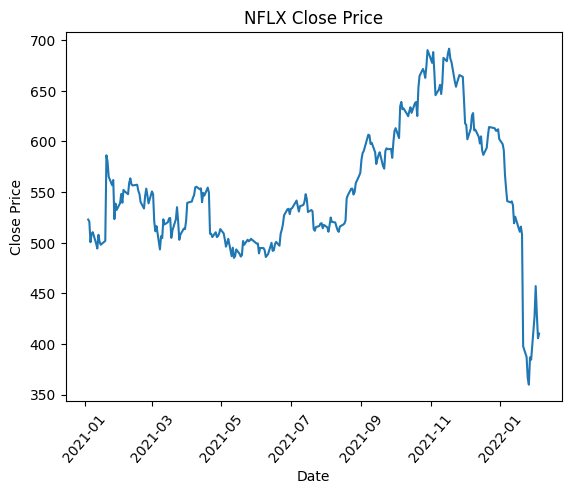

In [143]:
# 그래프 그리기
plt.plot(df3['Date'], df3['Close'])

# 그래프 가공
plt.title("NFLX Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation = 50)

# 그래프 출력
plt.show()

In [144]:
max_price = df3['Close'].max()
min_price = df3['Close'].min()

print("최고 종가:", max_price)
print("최저 종가:", min_price)

최고 종가: 691.690002
최저 종가: 359.700012


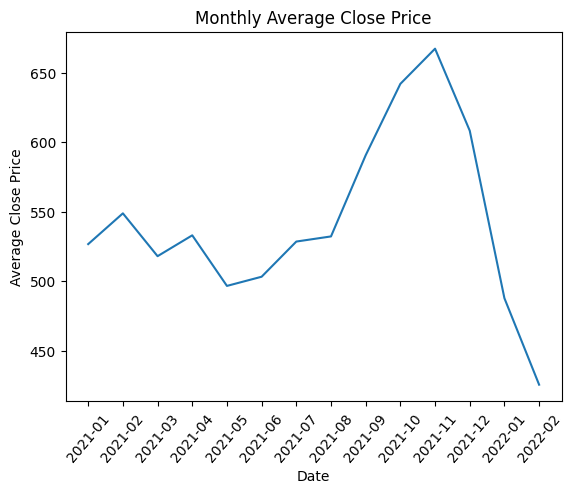

In [148]:
# 복사본
df4 = df3
df4['Year-Month']= df4['Date'].dt.strftime("%Y-%m")

df5 = df4[['Close','Year-Month']].groupby(['Year-Month']).mean().reset_index()

# 그래프 그리기
plt.plot(df5['Year-Month'], df5['Close'])

# 그래프 가공
plt.title("Monthly Average Close Price")

plt.xlabel("Date")
plt.xticks(rotation = 50)

plt.ylabel("Average Close Price")


# 그래프 출력
plt.show()

## F206 월별 최고/최저/종가 시각화

- 2022 년 이후의 데이터를 필터링하여, 월별 최고가, 최저가, 종가를 함께 표현하는 복합 라인 그래프를 작성
  

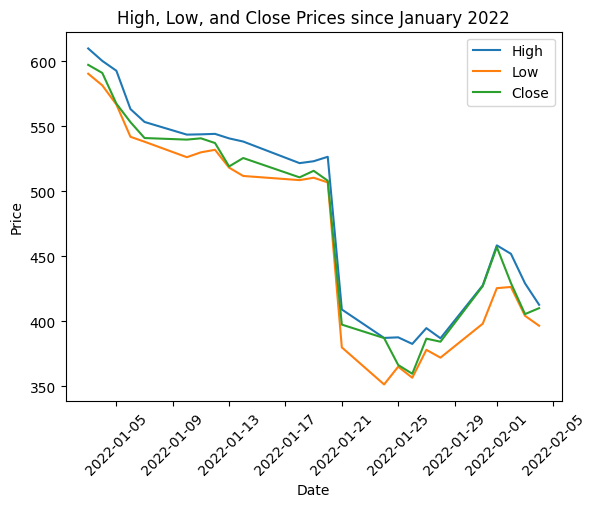

In [149]:
# CSV 파일 경로
csv_path = "achive/NFLX.csv"

df = pd.read_csv(csv_path)

# Datetype으로 변경
df['Date']=pd.to_datetime(df['Date'])

# data filtering
df = df[df['Date']>= "2022-01-01"]

# 그래프 그리기
plt.title("High, Low, and Close Prices since January 2022")

plt.plot(df['Date'], df['High'], label = 'High')
plt.plot(df['Date'], df['Low'], label = 'Low')
plt.plot(df['Date'], df['Close'], label = 'Close')

plt.xlabel('Date')
plt.xticks(rotation=45)

plt.ylabel("Price")

# 범례 표시
plt.legend()

# 그래프 출력
plt.show()